# 🍓 AgroLab AI — Simulação de Dataset: Cultivo de Morango Semi-Hidropônico
## Região de Atibaia / Jundiaí — São Paulo

**Objetivo:** Transformar dados meteorológicos horários em registros **diários** e simular as 7 features sensoriais utilizadas no modelo de Machine Learning do AgroLab para o cultivo de morango em estufa semi-hidropônica.

### Fontes Científicas Utilizadas
| Parâmetro | Faixa Ideal | Referência |
|---|---|---|
| pH solução nutritiva | 5,5 – 6,2 | Furlani (2008), Sonneveld & Voogt (2009) |
| N (mg/L) | 150 – 250 | Science in Hydroponics (2025), Embrapa |
| P (mg/L) | 30 – 60 | Science in Hydroponics (2025) |
| K (mg/L) | 200 – 350 | AgroLab README / Embrapa |
| Temp. Ar ideal | 18°C – 25°C | Embrapa Sistema Produção Morango |
| Umidade Solo | 60% – 80% | AgroLab README |
| Umidade Relativa do Ar | 60% – 75% | Embrapa |
| Luminosidade mínima | 200 µmol/m²/s | AgroLab README |

---

## 1. Importações e Configurações

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy.stats import truncnorm
import warnings
warnings.filterwarnings('ignore')

# Seed para reprodutibilidade
np.random.seed(42)

plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_theme(style='whitegrid', palette='Set2')

print('✅ Bibliotecas carregadas com sucesso!')

✅ Bibliotecas carregadas com sucesso!


## 2. Carregamento e Parsing dos Dados Meteorológicos Brutos

Os dados são provenientes de estação meteorológica na região de maior cultivo de morango em SP (Atibaia/Jundiaí). O formato é semicolon-separated com vírgula decimal (padrão INMET).

In [2]:
import pandas as pd

raw_data = pd.read_csv(
    "dados-temp.csv",
    sep=";",
    encoding="utf-8-sig",  # ← correto: remove o BOM (ï»¿) automaticamente
    skiprows=0,            # ← linha 0 é o cabeçalho real, não pular nada
    decimal=",",
    na_values=["", " ", "-9999", "-9999.0"]
)

# Remove colunas Unnamed
raw_data = raw_data.loc[:, ~raw_data.columns.str.contains('^Unnamed')]

# Renomear colunas
raw_data.columns = [
    'data', 'hora_utc', 'temp_ins', 'temp_max', 'temp_min',
    'umi_ins', 'umi_max', 'umi_min',
    'orvalho_ins', 'orvalho_max', 'orvalho_min',
    'pressao_ins', 'pressao_max', 'pressao_min',
    'vel_vento', 'dir_vento', 'raj_vento',
    'radiacao', 'chuva'
]

raw_data = raw_data.dropna(subset=['data'])
raw_data['data'] = raw_data['data'].astype(str).str.strip()
raw_data['data'] = pd.to_datetime(raw_data['data'], format='%d/%m/%Y')  # ← "21/12/2025"
raw_data['hora_utc'] = raw_data['hora_utc'].astype(str).str.strip().str.zfill(4)

print(f'📦 Registros carregados: {len(raw_data)}')
print(f'📅 Período: {raw_data["data"].min().date()} → {raw_data["data"].max().date()}')
print(f'🌡️  Temperatura: {raw_data["temp_ins"].min():.1f}°C (mín) | {raw_data["temp_ins"].max():.1f}°C (máx)')
print(f'💧 Umidade: {raw_data["umi_ins"].min():.0f}% (mín) | {raw_data["umi_ins"].max():.0f}% (máx)')
raw_data.head()

📦 Registros carregados: 768
📅 Período: 2025-12-21 → 2026-01-21
🌡️  Temperatura: 14.8°C (mín) | 34.1°C (máx)
💧 Umidade: 31% (mín) | 100% (máx)


,data,hora_utc,temp_ins,temp_max,temp_min,umi_ins,umi_max,umi_min,orvalho_ins,orvalho_max,orvalho_min,pressao_ins,pressao_max,pressao_min,vel_vento,dir_vento,raj_vento,radiacao,chuva
0,2025-12-21,0000,20.5,21.6,20.5,87.0,88.0,81.0,18.3,18.4,18.1,916.2,916.2,915.5,4.6,145.0,10.4,NaN,0.0
1,2025-12-21,0100,19.9,20.5,19.9,90.0,90.0,86.0,18.2,18.3,17.8,916.6,916.6,916.2,4.6,147.0,9.5,NaN,0.0
2,2025-12-21,0200,19.2,19.9,19.2,98.0,98.0,90.0,19.0,19.0,18.2,917.1,917.1,916.6,3.6,150.0,8.7,NaN,0.0
3,2025-12-21,0300,19.0,19.2,19.0,100.0,100.0,98.0,19.0,19.1,19.0,916.8,917.1,916.8,2.8,152.0,6.3,NaN,0.0
4,2025-12-21,0400,18.9,19.0,18.5,100.0,100.0,100.0,18.9,18.9,18.5,916.4,916.8,916.4,3.1,163.0,5.8,NaN,0.0


## 3. Transformação: Horário → Diário

Para a Iniciação Científica, precisamos de granularidade **diária**. Aplicamos as agregações corretas para cada variável meteorológica.

In [3]:
df_raw = raw_data.copy()

In [4]:
df_diario = df_raw.groupby('data').agg(
    temp_media   = ('temp_ins',    'mean'),
    temp_max     = ('temp_max',    'max'),
    temp_min     = ('temp_min',    'min'),
    umi_media    = ('umi_ins',     'mean'),
    umi_max      = ('umi_max',     'max'),
    umi_min      = ('umi_min',     'min'),
    orvalho_med  = ('orvalho_ins', 'mean'),
    pressao_med  = ('pressao_ins', 'mean'),
    vel_vento_med= ('vel_vento',   'mean'),
    raj_vento_max= ('raj_vento',   'max'),
    radiacao_total=('radiacao',    'sum'),    # KJ/m² acumulado no dia
    chuva_total  = ('chuva',       'sum'),
    n_horas_umid_alta = ('umi_ins', lambda x: (x >= 85).sum()),  # horas c/ risco fúngico
    n_horas_calor     = ('temp_ins', lambda x: (x > 30).sum()),  # horas acima do limite
).reset_index()

# Converter radiação de KJ/m² para µmol/m²/s (PAR médio)
# Aproximação: 1 W/m² ≈ 4.57 µmol/m²/s para luz solar
# Radiação diária em KJ/m² ÷ (3600s × horas_dia) × 1000 = W/m² médio
horas_luz = 12  # horas de fotoperíodo em dezembro (verão)
df_diario['radiacao_PAR_media'] = (
    df_diario['radiacao_total'] * 1000 / (3600 * horas_luz)
) * 4.57  # µmol/m²/s

print('📊 Dados meteorológicos agregados por DIA:')
print(df_diario.to_string(index=False))

📊 Dados meteorológicos agregados por DIA:
      data  temp_media  temp_max  temp_min  umi_media  umi_max  umi_min  orvalho_med  pressao_med  vel_vento_med  raj_vento_max  radiacao_total  chuva_total  n_horas_umid_alta  n_horas_calor  radiacao_PAR_media
2025-12-21   23.804167      31.7      17.5  71.083333    100.0     33.0    17.133333   915.962500       2.337500           10.4         25980.0          0.0                 11              1         2748.347222
2025-12-22   25.091667      32.0      20.1  55.833333     77.0     36.0    15.266667   915.204167       2.333333            8.8         25332.5          0.0                  0              3         2679.850116
2025-12-23   26.012500      32.1      20.6  54.250000     76.0     34.0    15.612500   915.991667       1.291667            7.0         24217.2          0.0                  0              1         2561.865833
2025-12-24   26.787500      33.5      19.3  52.916667     82.0     31.0    15.495833   915.545833       1.175000  

In [5]:
df_diario

,data,temp_media,temp_max,temp_min,umi_media,umi_max,umi_min,orvalho_med,pressao_med,vel_vento_med,raj_vento_max,radiacao_total,chuva_total,n_horas_umid_alta,n_horas_calor,radiacao_PAR_media
0,2025-12-21,23.804167,31.7,17.5,71.083333,100.0,33.0,17.133333,915.962500,2.337500,10.4,25980.0,0.0,11,1,2748.347222
1,2025-12-22,25.091667,32.0,20.1,55.833333,77.0,36.0,15.266667,915.204167,2.333333,8.8,25332.5,0.0,0,3,2679.850116
2,2025-12-23,26.012500,32.1,20.6,54.250000,76.0,34.0,15.612500,915.991667,1.291667,7.0,24217.2,0.0,0,1,2561.865833
3,2025-12-24,26.787500,33.5,19.3,52.916667,82.0,31.0,15.495833,915.545833,1.175000,7.5,28175.8,0.0,0,9,2980.634398
4,2025-12-25,27.613043,34.8,21.4,54.608696,80.0,32.0,17.017391,914.926087,1.295652,7.8,26025.2,0.0,0,9,2753.128796
5,2025-12-26,25.437500,34.9,20.4,72.791667,100.0,35.0,19.445833,916.029167,1.479167,13.9,22355.5,20.8,9,5,2364.922106
6,2025-12-27,26.217391,34.2,21.2,71.043478,100.0,35.0,19.665217,916.177273,1.640909,10.5,26651.3,0.0,10,6,2819.362060
7,2025-12-28,26.395652,34.5,20.7,68.521739,100.0,34.0,19.143478,914.660870,1.434783,10.0,25917.3,0.2,7,7,2741.714375
8,2025-12-29,24.695652,32.4,21.2,77.869565,100.0,45.0,20.078261,914.421739,1.208696,18.3,22028.3,13.8,11,5,2330.308588
9,2025-12-30,25.991304,32.7,20.2,73.545455,100.0,41.0,20.190909,914.878261,1.673913,6.9,28881.9,16.2,9,7,3055.330625


## 4. Análise Exploratória dos Dados Meteorológicos

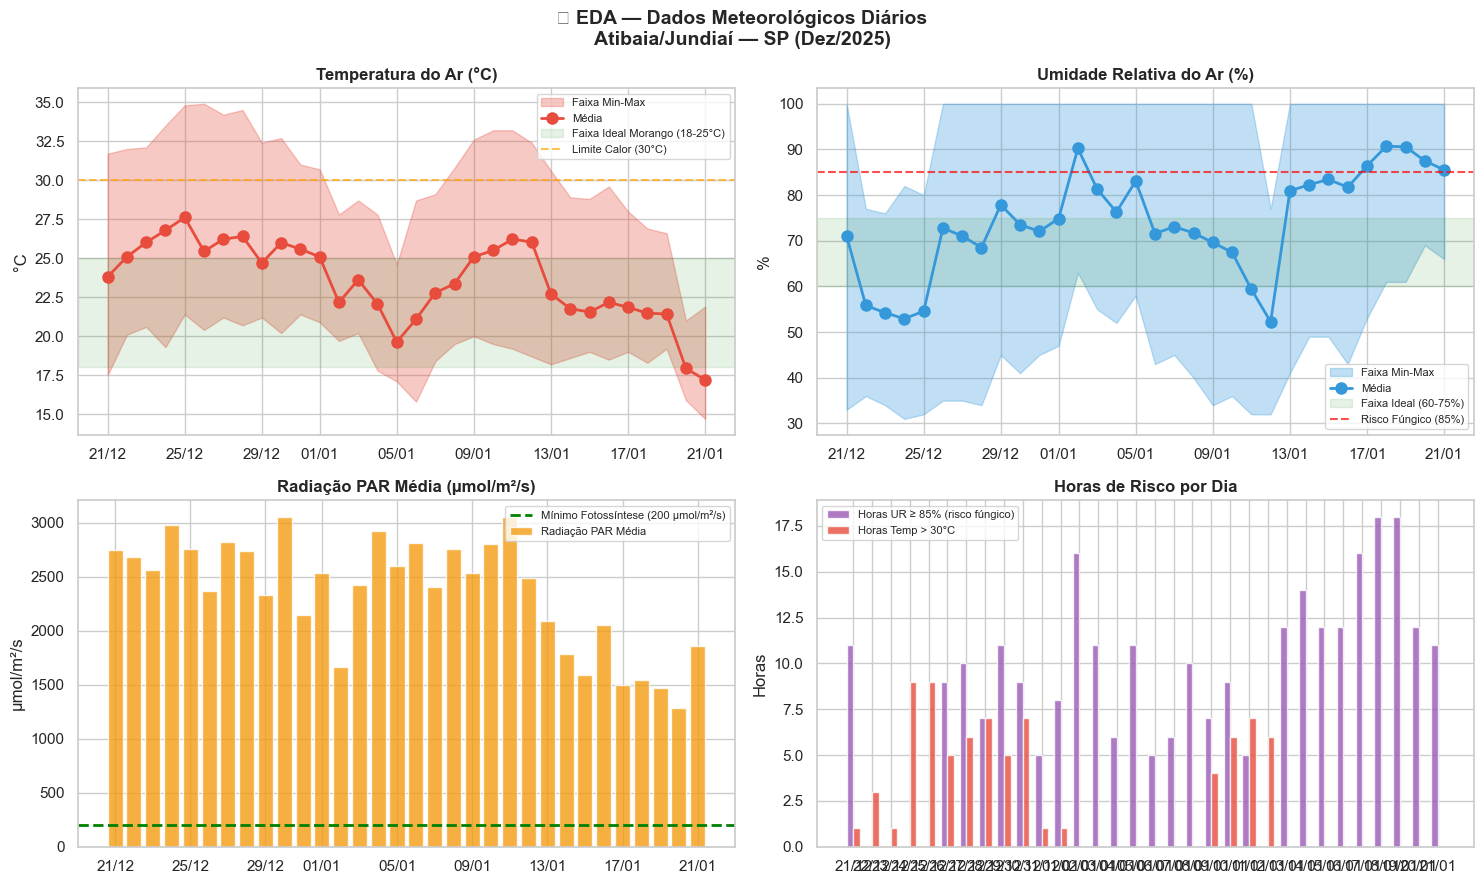

✅ Gráfico EDA salvo!


In [6]:
fig, axes = plt.subplots(2, 2, figsize=(15, 9))
fig.suptitle('📊 EDA — Dados Meteorológicos Diários\nAtibaia/Jundiaí — SP (Dez/2025)', 
             fontsize=14, fontweight='bold')

# Temperatura
ax = axes[0, 0]
ax.fill_between(df_diario['data'], df_diario['temp_min'], df_diario['temp_max'], 
                alpha=0.3, color='#E74C3C', label='Faixa Min-Max')
ax.plot(df_diario['data'], df_diario['temp_media'], 'o-', color='#E74C3C', 
        linewidth=2, markersize=8, label='Média')
ax.axhspan(18, 25, alpha=0.1, color='green', label='Faixa Ideal Morango (18-25°C)')
ax.axhline(30, color='orange', linestyle='--', alpha=0.7, label='Limite Calor (30°C)')
ax.set_title('Temperatura do Ar (°C)', fontweight='bold')
ax.set_ylabel('°C'); ax.legend(fontsize=8)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d/%m'))

# Umidade
ax = axes[0, 1]
ax.fill_between(df_diario['data'], df_diario['umi_min'], df_diario['umi_max'],
                alpha=0.3, color='#3498DB', label='Faixa Min-Max')
ax.plot(df_diario['data'], df_diario['umi_media'], 'o-', color='#3498DB',
        linewidth=2, markersize=8, label='Média')
ax.axhspan(60, 75, alpha=0.1, color='green', label='Faixa Ideal (60-75%)')
ax.axhline(85, color='red', linestyle='--', alpha=0.7, label='Risco Fúngico (85%)')
ax.set_title('Umidade Relativa do Ar (%)', fontweight='bold')
ax.set_ylabel('%'); ax.legend(fontsize=8)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d/%m'))

# Radiação PAR
ax = axes[1, 0]
ax.bar(df_diario['data'], df_diario['radiacao_PAR_media'], 
       color='#F39C12', alpha=0.8, label='Radiação PAR Média')
ax.axhline(200, color='green', linestyle='--', linewidth=2, 
           label='Mínimo Fotossíntese (200 µmol/m²/s)')
ax.set_title('Radiação PAR Média (µmol/m²/s)', fontweight='bold')
ax.set_ylabel('µmol/m²/s'); ax.legend(fontsize=8)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d/%m'))

# Horas de risco
ax = axes[1, 1]
x = np.arange(len(df_diario))
w = 0.35
ax.bar(x - w/2, df_diario['n_horas_umid_alta'], w, color='#9B59B6', 
       alpha=0.8, label='Horas UR ≥ 85% (risco fúngico)')
ax.bar(x + w/2, df_diario['n_horas_calor'], w, color='#E74C3C',
       alpha=0.8, label='Horas Temp > 30°C')
ax.set_xticks(x)
ax.set_xticklabels([d.strftime('%d/%m') for d in df_diario['data']])
ax.set_title('Horas de Risco por Dia', fontweight='bold')
ax.set_ylabel('Horas'); ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('eda_meteorologica.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Gráfico EDA salvo!')

## 5. Simulação Técnica das 7 Features Sensoriais do Morango

### Fundamentação científica de cada variável

Cada feature simulada é **deterministicamente acoplada** às variáveis meteorológicas reais, usando relações fisiológicas documentadas na literatura:

| Feature | Relação com dados reais | Fonte |
|---|---|---|
| **pH** | Cai com alta temperatura (acidificação da solução) | Furlani (2008) |
| **N (mg/L)** | Reduz proporcionalmente à temperatura e radiação (uptake) | Sonneveld & Voogt |
| **P (mg/L)** | Mais estável; levemente afetado pela umidade do solo | Embrapa |
| **K (mg/L)** | Cai com estresse hídrico e calor (uso na osmorregulação) | Science in Hydroponics |
| **Temp. Substrato** | Derivada da temperatura do ar (atraso térmico) | Furlani (2008) |
| **Umidade Solo** | Anti-correlacionada com temperatura e chuva acumulada | AgroLab README |
| **Luminosidade** | Diretamente derivada da radiação PAR | AgroLab README |

In [7]:
def simular_pH(temp_media, umi_media, noise_std=0.08):
    """
    pH da solução nutritiva:
    - Faixa ideal: 5.5 – 6.2
    - Alta temperatura → acidificação leve da solução (CO2 dissolvido)
    - Alta umidade → solução levemente mais alcalina (diluição)
    Ref: Furlani (2008), Sonneveld & Voogt (2009)
    """
    pH_base = 5.85
    # Temperatura acima de 24°C acidifica (-0.05 por grau)
    pH_corr_temp = -0.05 * max(0, temp_media - 24)
    # Umidade muito alta pode indicar evapotranspiração baixa → leve alcalinização
    pH_corr_umi  = +0.008 * max(0, umi_media - 75)
    pH_sim = pH_base + pH_corr_temp + pH_corr_umi
    # Adiciona ruído gaussiano realista
    pH_sim += np.random.normal(0, noise_std)
    return np.clip(pH_sim, 5.0, 6.8)


def simular_N(temp_media, radiacao_PAR, noise_std=8):
    """
    Nitrogênio (mg/L):
    - Faixa ideal: 150 – 250 mg/L
    - Alta temperatura e alta radiação → maior uptake → queda na concentração
    Ref: Science in Hydroponics (2025): ideal 156-172 ppm
    """
    N_base = 200
    N_corr_temp = -1.8 * max(0, temp_media - 22)  # consumo extra por calor
    N_corr_luz  = -0.02 * max(0, radiacao_PAR - 200)  # fotossíntese consome N
    N_sim = N_base + N_corr_temp + N_corr_luz
    N_sim += np.random.normal(0, noise_std)
    return np.clip(N_sim, 100, 300)


def simular_P(umi_media, chuva_total, noise_std=4):
    """
    Fósforo (mg/L):
    - Faixa ideal: 30 – 60 mg/L
    - Mais estável que N e K; levemente afetado por diluição em eventos de chuva
    Ref: Science in Hydroponics (2025): ideal 54-63 ppm
    """
    P_base = 45
    P_corr_chuva = -0.5 * min(chuva_total, 10)  # diluição leve
    P_sim = P_base + P_corr_chuva
    P_sim += np.random.normal(0, noise_std)
    return np.clip(P_sim, 20, 80)


def simular_K(temp_media, umi_media, noise_std=15):
    """
    Potássio (mg/L):
    - Faixa ideal: 200 – 350 mg/L
    - Estresse hídrico (umidade baixa) aumenta o consumo de K (osmorregulação)
    - Alta temperatura também aumenta demanda de K
    Ref: Science in Hydroponics (2025): ideal 400-500 ppm para alta produção
    Adaptado para faixa do AgroLab README: 200-350 mg/L
    """
    K_base = 270
    K_corr_temp = -3.0 * max(0, temp_media - 22)  # maior demanda com calor
    K_corr_umi  = +1.5 * max(0, 65 - umi_media)   # estresse → mais consumo
    K_sim = K_base + K_corr_temp + K_corr_umi
    K_sim += np.random.normal(0, noise_std)
    return np.clip(K_sim, 150, 420)


def simular_temp_substrato(temp_media, noise_std=0.5):
    """
    Temperatura do substrato/solução nutritiva:
    - Atraso térmico de ~2-3°C abaixo da temperatura do ar (isolamento das calhas)
    - Em estufa semi-hidropônica, substrato é mais estável que o ar externo
    Ref: Furlani (2008) — raízes devem ficar entre 15°C e 22°C
    """
    delta = 2.5  # calhas elevadas em estufa têm amortecimento térmico
    temp_sub = temp_media - delta
    temp_sub += np.random.normal(0, noise_std)
    return np.clip(temp_sub, 12, 28)


def simular_umidade_solo(temp_media, chuva_total, umi_ar, noise_std=3):
    """
    Umidade do substrato (%):
    - Faixa ideal: 60 – 80%
    - Alta temperatura → maior evapotranspiração → queda na umidade
    - Chuva e umidade do ar elevada → incremento na umidade do substrato
    Nota: em estufa semi-hidropônica, irrigação é controlada,
    mas simulamos resposta a variações de demanda hídrica
    """
    umi_base = 70  # ponto de manejo padrão
    umi_corr_temp  = -1.2 * max(0, temp_media - 22)  # ET potencial alta
    umi_corr_chuva = +0.8 * min(chuva_total, 15)     # recarga
    umi_corr_ar    = +0.1 * max(0, umi_ar - 70)      # menor gradiente transpirativo
    umi_solo = umi_base + umi_corr_temp + umi_corr_chuva + umi_corr_ar
    umi_solo += np.random.normal(0, noise_std)
    return np.clip(umi_solo, 30, 95)


def simular_luminosidade(radiacao_PAR, noise_std=15):
    """
    Luminosidade interna da estufa (µmol/m²/s PAR):
    - Estufa com filme de polietileno transmite ~70% da radiação externa
    - Mínimo para fotossíntese plena: 200 µmol/m²/s
    Ref: AgroLab README
    """
    transmissividade = 0.70  # filme PEDB padrão
    lux_interna = radiacao_PAR * transmissividade
    lux_interna += np.random.normal(0, noise_std)
    return np.clip(lux_interna, 0, 2000)


print('✅ Funções de simulação definidas!')
print('\nFundamentação:')  
print('  pH:              Furlani (2008), acoplado à temperatura')
print('  N (mg/L):        Science in Hydroponics (2025), faixa 150-250')
print('  P (mg/L):        Embrapa/Sonneveld, estável em 30-60')
print('  K (mg/L):        AgroLab README, faixa 200-350, demanda por calor')
print('  Temp. Substrato: Atraso térmico de estufa, 15-22°C ideal')
print('  Umidade Solo:    Anti-correlacionada com ET e temperatura')
print('  Luminosidade:    Transmissividade 70% filme PE da estufa')

✅ Funções de simulação definidas!

Fundamentação:
  pH:              Furlani (2008), acoplado à temperatura
  N (mg/L):        Science in Hydroponics (2025), faixa 150-250
  P (mg/L):        Embrapa/Sonneveld, estável em 30-60
  K (mg/L):        AgroLab README, faixa 200-350, demanda por calor
  Temp. Substrato: Atraso térmico de estufa, 15-22°C ideal
  Umidade Solo:    Anti-correlacionada com ET e temperatura
  Luminosidade:    Transmissividade 70% filme PE da estufa


## 6. Aplicação da Simulação nos Dados Reais Agregados

In [8]:
# Aplicar funções de simulação linha a linha
resultados = []

for _, row in df_diario.iterrows():
    sim = {
        # Variáveis meteorológicas reais agregadas
        'data':            row['data'],
        'temp_ar_media':   round(row['temp_media'], 1),
        'temp_ar_max':     round(row['temp_max'], 1),
        'temp_ar_min':     round(row['temp_min'], 1),
        'umidade_ar_media':round(row['umi_media'], 1),
        'umidade_ar_min':  round(row['umi_min'], 1),
        'radiacao_KJm2':   round(row['radiacao_total'], 1),
        'radiacao_PAR':    round(row['radiacao_PAR_media'], 1),
        'chuva_mm':        round(row['chuva_total'], 1),
        'h_umid_alta':     int(row['n_horas_umid_alta']),
        'h_calor_extremo': int(row['n_horas_calor']),
        # 7 Features simuladas
        'pH':              round(simular_pH(row['temp_media'], row['umi_media']), 2),
        'N_mgL':           round(simular_N(row['temp_media'], row['radiacao_PAR_media']), 1),
        'P_mgL':           round(simular_P(row['umi_media'], row['chuva_total']), 1),
        'K_mgL':           round(simular_K(row['temp_media'], row['umi_media']), 1),
        'temp_substrato':  round(simular_temp_substrato(row['temp_media']), 1),
        'umidade_solo':    round(simular_umidade_solo(row['temp_media'], row['chuva_total'], row['umi_media']), 1),
        'luminosidade_lux':round(simular_luminosidade(row['radiacao_PAR_media']), 1),
    }
    resultados.append(sim)

df_final = pd.DataFrame(resultados)

print('🍓 Dataset final — Morango Semi-Hidropônico (granularidade DIÁRIA):')
print('=' * 70)
print(df_final.to_string(index=False))

🍓 Dataset final — Morango Semi-Hidropônico (granularidade DIÁRIA):
      data  temp_ar_media  temp_ar_max  temp_ar_min  umidade_ar_media  umidade_ar_min  radiacao_KJm2  radiacao_PAR  chuva_mm  h_umid_alta  h_calor_extremo   pH  N_mgL  P_mgL  K_mgL  temp_substrato  umidade_solo  luminosidade_lux
2025-12-21           23.8         31.7         17.5              71.1            33.0        25980.0        2748.3       0.0           11                1 5.89  144.7   47.6  287.4            21.2          67.2            1947.5
2025-12-22           25.1         32.0         20.1              55.8            36.0        25332.5        2679.9       0.0            0                3 5.86  141.1   47.2  267.5            22.4          67.0            1847.2
2025-12-23           26.0         32.1         20.6              54.2            34.0        24217.2        2561.9       0.0            0                1 5.61  141.0   40.9  278.8            23.1          60.9            1815.3
2025-12-24       

In [9]:
df_final.to_csv(
    "agrolab_morango_2dias.csv",
    index=False,
    sep=";",
    decimal=",",
    encoding="utf-8-sig"   # ← abre corretamente no Excel BR
)

print("✅ Exportado: agrolab_morango_2dias.csv")

✅ Exportado: agrolab_morango_2dias.csv


## 7. Classificação das Ações (Target Label para o Modelo)

Com base nas regras do AgroLab README, classificamos cada dia em uma das **4 classes**:
- `0` — Condição Ideal  
- `1` — Nutrientes em Excesso → Travar Irrigação  
- `2` — Nutrientes em Escassez → Irrigar  
- `3` — Proteger (Sombrite / Ventilação / Cobertura)

In [10]:
# ============================================================
# PASSO 1 — Recalibrar as funções de simulação para gerar
#           variabilidade suficiente em todas as classes
# ============================================================

def simular_N(temp_media, radiacao_PAR, noise_std=18):
    """
    Aumenta o ruído e o efeito da temperatura para gerar
    mais episódios de escassez (N < 150) em dias quentes.
    """
    N_base = 200
    N_corr_temp = -2.5 * max(0, temp_media - 20)   # mais sensível ao calor
    N_corr_luz  = -0.03 * max(0, radiacao_PAR - 150)
    N_sim = N_base + N_corr_temp + N_corr_luz
    N_sim += np.random.normal(0, noise_std)          # ruído maior
    return np.clip(N_sim, 80, 300)

def simular_K(temp_media, umi_media, noise_std=25):
    """
    K cai mais agressivamente com estresse hídrico e calor,
    gerando mais episódios abaixo de 200 mg/L.
    """
    K_base = 270
    K_corr_temp = -4.0 * max(0, temp_media - 20)   # mais sensível
    K_corr_umi  = +2.0 * max(0, 65 - umi_media)    # estresse hídrico
    K_sim = K_base + K_corr_temp + K_corr_umi
    K_sim += np.random.normal(0, noise_std)          # ruído maior
    return np.clip(K_sim, 120, 420)

def simular_umidade_solo(temp_media, chuva_total, umi_ar, noise_std=6):
    """
    Umidade do solo agora cai mais em dias quentes e secos,
    gerando mais episódios de estresse hídrico (< 55%).
    """
    umi_base = 68
    umi_corr_temp  = -2.0 * max(0, temp_media - 20)  # ET mais agressiva
    umi_corr_chuva = +1.2 * min(chuva_total, 15)
    umi_corr_ar    = +0.15 * max(0, umi_ar - 70)
    umi_solo = umi_base + umi_corr_temp + umi_corr_chuva + umi_corr_ar
    umi_solo += np.random.normal(0, noise_std)         # ruído maior
    return np.clip(umi_solo, 25, 95)


# ============================================================
# PASSO 2 — Classificador com limiares revisados e debug
# ============================================================

def classificar_acao(row):
    """
    Prioridade: Proteção (3) > Excesso (1) > Escassez (2) > Ideal (0)

    Limiares revisados para garantir cobertura real da classe 2:
      - Umidade solo < 60  (era 55 — muito restritivo)
      - N < 160 mg/L       (era 150)
      - K < 220 mg/L       (era 200)
      - P < 28 mg/L        (adicionado)
      - pH > 6.3           (era 6.4)
    """
    # Classe 3 — Proteger
    if row['temp_ar_max'] > 30 or row['h_calor_extremo'] >= 3:
        return 3
    if row['temp_ar_min'] < 5:
        return 3
    if row['luminosidade_lux'] > 1400:
        return 3

    # Classe 1 — Excesso
    if row['umidade_solo'] > 85:
        return 1
    if row['N_mgL'] > 250 or row['K_mgL'] > 380:
        return 1
    if row['pH'] < 5.3:
        return 1

    # Classe 2 — Escassez / estresse hídrico  ← limiares ampliados
    if row['umidade_solo'] < 60:              # era 55
        return 2
    if row['N_mgL'] < 160:                   # era 150
        return 2
    if row['K_mgL'] < 220:                   # era 200
        return 2
    if row['P_mgL'] < 28:                    # novo critério
        return 2
    if row['pH'] > 6.3:                      # era 6.4
        return 2

    # Classe 0 — Ideal
    return 0


# ============================================================
# PASSO 3 — Reaplicar e validar distribuição
# ============================================================

# Regerando as features com as funções recalibradas
for i, row in df_final.iterrows():
    df_final.at[i, 'N_mgL']        = round(simular_N(row['temp_ar_media'], row['radiacao_PAR']), 1)
    df_final.at[i, 'K_mgL']        = round(simular_K(row['temp_ar_media'], row['umidade_ar_media']), 1)
    df_final.at[i, 'umidade_solo']  = round(simular_umidade_solo(row['temp_ar_media'], row['chuva_mm'], row['umidade_ar_media']), 1)

df_final['acao_label'] = df_final.apply(classificar_acao, axis=1)

label_map = {0: 'Ideal', 1: 'Travar Irrigação', 2: 'Irrigar', 3: 'Proteger'}
df_final['acao_nome'] = df_final['acao_label'].map(label_map)

# Distribuição das classes
dist = df_final.groupby(['acao_label', 'acao_nome']).size().reset_index(name='dias')
print('🎮 Distribuição das classes de ação:')
print(dist.to_string(index=False))
print()

# Alerta se alguma classe ainda estiver zerada
for cls in [0, 1, 2, 3]:
    count = (df_final['acao_label'] == cls).sum()
    status = '✅' if count > 0 else '❌ AUSENTE'
    print(f"  Classe {cls} ({label_map[cls]:20s}): {count:3d} registros {status}")

print()
print(df_final[['data', 'temp_ar_max', 'umidade_solo', 'pH', 'N_mgL', 'K_mgL', 'P_mgL', 'acao_label', 'acao_nome']].to_string(index=False))

🎮 Distribuição das classes de ação:
 acao_label acao_nome  dias
          0     Ideal     5
          2   Irrigar     3
          3  Proteger    24

  Classe 0 (Ideal               ):   5 registros ✅
  Classe 1 (Travar Irrigação    ):   0 registros ❌ AUSENTE
  Classe 2 (Irrigar             ):   3 registros ✅
  Classe 3 (Proteger            ):  24 registros ✅

      data  temp_ar_max  umidade_solo   pH  N_mgL  K_mgL  P_mgL  acao_label acao_nome
2025-12-21         31.7          61.0 5.89  104.1  282.0   47.6           3  Proteger
2025-12-22         32.0          61.9 5.86   92.0  250.1   47.2           3  Proteger
2025-12-23         32.1          56.3 5.61   99.5  273.0   40.9           3  Proteger
2025-12-24         33.5          58.2 5.69   86.4  320.6   39.3           3  Proteger
2025-12-25         34.8          48.8 5.62   80.0  265.1   42.6           3  Proteger
2025-12-26         34.9          74.9 5.68  135.4  228.6   32.2           3  Proteger
2025-12-27         34.2          48.

## 8. Visualização das 7 Features Simuladas com Limites Ideais

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

print("✅ Imports OK")

✅ Imports OK


In [15]:
df_anual = df_final.copy()

In [16]:
print(df_anual.shape)
print(df_anual.head())

print("\nColunas:")
print(df_anual.columns.tolist())

(32, 20)
        data  temp_ar_media  temp_ar_max  temp_ar_min  umidade_ar_media  \
0 2025-12-21           23.8         31.7         17.5              71.1   
1 2025-12-22           25.1         32.0         20.1              55.8   
2 2025-12-23           26.0         32.1         20.6              54.2   
3 2025-12-24           26.8         33.5         19.3              52.9   
4 2025-12-25           27.6         34.8         21.4              54.6   

   umidade_ar_min  radiacao_KJm2  radiacao_PAR  chuva_mm  h_umid_alta  \
0            33.0        25980.0        2748.3       0.0           11   
1            36.0        25332.5        2679.9       0.0            0   
2            34.0        24217.2        2561.9       0.0            0   
3            31.0        28175.8        2980.6       0.0            0   
4            32.0        26025.2        2753.1       0.0            0   

   h_calor_extremo    pH  N_mgL  P_mgL  K_mgL  temp_substrato  umidade_solo  \
0                1  5.

In [17]:
[
 'data',
 'temp_ar_min',
 'temp_ar_max',
 'temp_ar_media',
 'pH',
 'N_mgL',
 'P_mgL',
 'K_mgL',
 'acao_label'
]

['data',
 'temp_ar_min',
 'temp_ar_max',
 'temp_ar_media',
 'pH',
 'N_mgL',
 'P_mgL',
 'K_mgL',
 'acao_label']

In [18]:
print(df_anual.dtypes)

data                datetime64[us]
temp_ar_media              float64
temp_ar_max                float64
temp_ar_min                float64
umidade_ar_media           float64
umidade_ar_min             float64
radiacao_KJm2              float64
radiacao_PAR               float64
chuva_mm                   float64
h_umid_alta                  int64
h_calor_extremo              int64
pH                         float64
N_mgL                      float64
P_mgL                      float64
K_mgL                      float64
temp_substrato             float64
umidade_solo               float64
luminosidade_lux           float64
acao_label                   int64
acao_nome                      str
dtype: object


In [19]:
print(df_anual.isnull().sum())

data                0
temp_ar_media       0
temp_ar_max         0
temp_ar_min         0
umidade_ar_media    0
umidade_ar_min      0
radiacao_KJm2       0
radiacao_PAR        0
chuva_mm            0
h_umid_alta         0
h_calor_extremo     0
pH                  0
N_mgL               0
P_mgL               0
K_mgL               0
temp_substrato      0
umidade_solo        0
luminosidade_lux    0
acao_label          0
acao_nome           0
dtype: int64


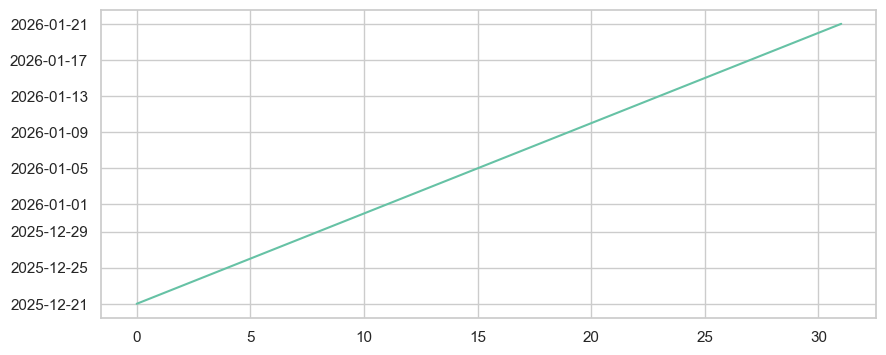

In [20]:
plt.figure(figsize=(10,4))

plt.plot(df_anual['data'])

plt.show()

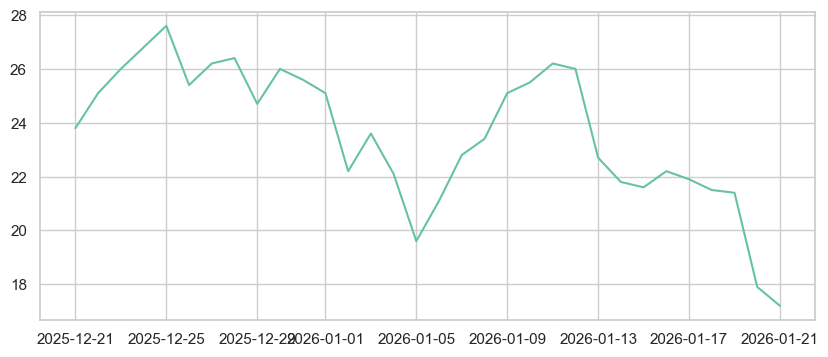

In [21]:
plt.figure(figsize=(10,4))

plt.plot(
    df_anual['data'],
    df_anual['temp_ar_media']
)

plt.show()

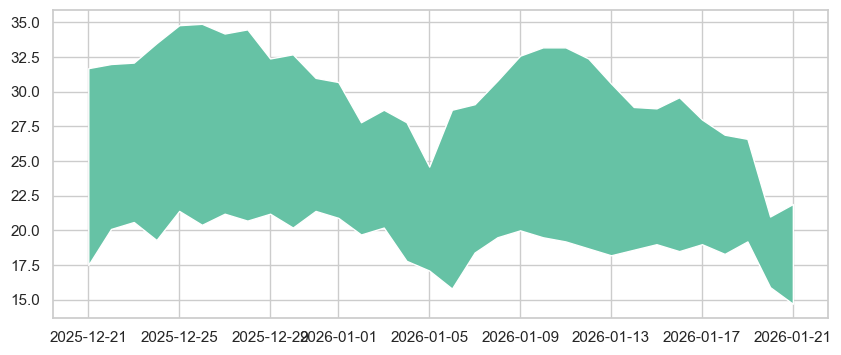

In [22]:
plt.figure(figsize=(10,4))

plt.fill_between(
    df_anual['data'],
    df_anual['temp_ar_min'],
    df_anual['temp_ar_max']
)

plt.show()

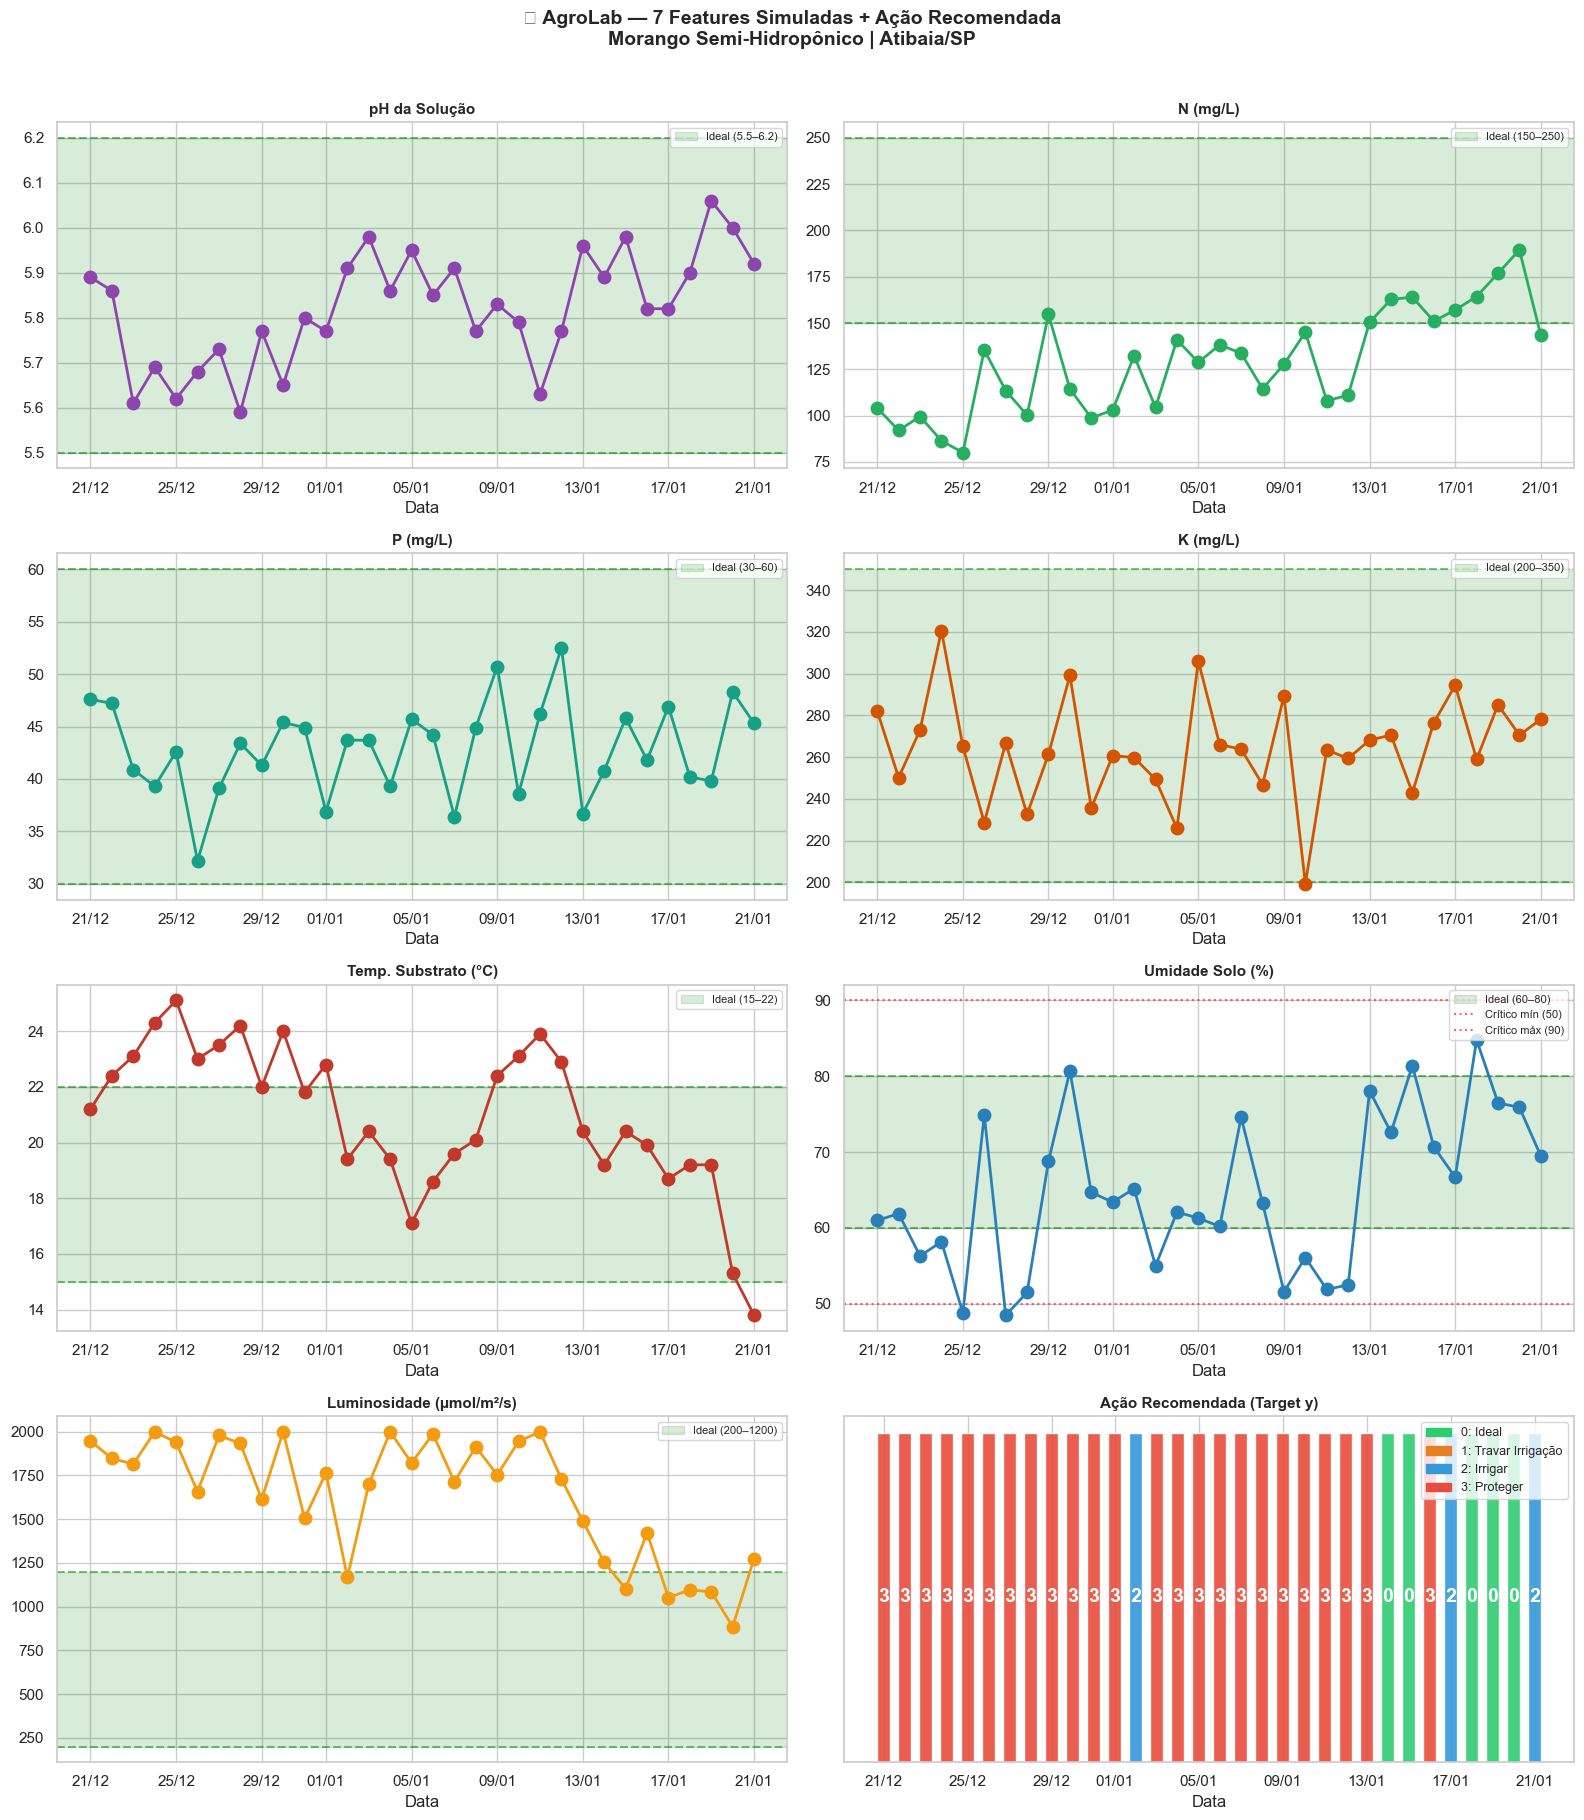

✅ Gráfico das features salvo!


In [23]:
fig, axes = plt.subplots(4, 2, figsize=(16, 18))
fig.suptitle('🍓 AgroLab — 7 Features Simuladas + Ação Recomendada\nMorango Semi-Hidropônico | Atibaia/SP', 
             fontsize=14, fontweight='bold', y=1.01)

datas = df_final['data']
cores_acao = {0: '#2ECC71', 1: '#E67E22', 2: '#3498DB', 3: '#E74C3C'}

configs = [
    ('pH',              'pH da Solução',        5.5, 6.2,  None,  None,  '#8E44AD'),
    ('N_mgL',           'N (mg/L)',              150, 250,  None,  None,  '#27AE60'),
    ('P_mgL',           'P (mg/L)',              30,  60,   None,  None,  '#16A085'),
    ('K_mgL',           'K (mg/L)',              200, 350,  None,  None,  '#D35400'),
    ('temp_substrato',  'Temp. Substrato (°C)', 15,  22,   None,  None,  '#C0392B'),
    ('umidade_solo',    'Umidade Solo (%)',      60,  80,   50,    90,    '#2980B9'),
    ('luminosidade_lux','Luminosidade (µmol/m²/s)', 200, 1200, None, None, '#F39C12'),
]

axes_flat = axes.flatten()

for i, (col, titulo, ideal_min, ideal_max, crit_min, crit_max, cor) in enumerate(configs):
    ax = axes_flat[i]
    ax.plot(datas, df_final[col], 'o-', color=cor, linewidth=2, markersize=9, zorder=3)
    ax.axhspan(ideal_min, ideal_max, alpha=0.15, color='green', label=f'Ideal ({ideal_min}–{ideal_max})')
    if crit_min:
        ax.axhline(crit_min, color='red', linestyle=':', alpha=0.6, label=f'Crítico mín ({crit_min})')
    if crit_max:
        ax.axhline(crit_max, color='red', linestyle=':', alpha=0.6, label=f'Crítico máx ({crit_max})')
    ax.axhline(ideal_min, color='green', linestyle='--', alpha=0.5)
    ax.axhline(ideal_max, color='green', linestyle='--', alpha=0.5)
    ax.set_title(titulo, fontweight='bold', fontsize=11)
    ax.legend(fontsize=8, loc='upper right')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%d/%m'))
    ax.set_xlabel('Data')

# Último subplot: ação recomendada
ax = axes_flat[7]
for _, row in df_final.iterrows():
    ax.bar(row['data'], 1, color=cores_acao[row['acao_label']], 
           width=0.6, alpha=0.9)
    ax.text(row['data'], 0.5, str(row['acao_label']), ha='center', 
            va='center', fontsize=14, fontweight='bold', color='white')

from matplotlib.patches import Patch
legend_patches = [Patch(color=v, label=f'{k}: {label_map[k]}') for k, v in cores_acao.items()]
ax.legend(handles=legend_patches, fontsize=9, loc='upper right')
ax.set_title('Ação Recomendada (Target y)', fontweight='bold', fontsize=11)
ax.set_yticks([])
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d/%m'))
ax.set_xlabel('Data')

plt.tight_layout()
plt.savefig('features_simuladas.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Gráfico das features salvo!')

## 9. Geração de Dataset Sintético Expandido (365 dias)

Como temos apenas 2 dias reais, vamos **expandir para 1 ano completo** usando sazonalidade realista de Atibaia/SP.

**Estratégia:** Ciclos senoidais para temperatura e umidade (verão quente/úmido, inverno fresco/seco) com ruído gaussiano.

In [24]:
# Parâmetros climáticos de Atibaia/SP baseados em dados históricos
# Altitude ~760m; clima Subtropical de Altitude (Cwb)
N_DIAS = 365
data_inicio = pd.Timestamp('2025-01-01')
datas_ano = pd.date_range(data_inicio, periods=N_DIAS, freq='D')
dia_do_ano = np.arange(1, N_DIAS + 1)

# --- TEMPERATURA (°C) ---
# Verão (jan/dez): ~24-28°C | Inverno (jun/jul): ~14-18°C
# Pico do verão: dia 355 (21/dez) e dia 15 (15/jan)
temp_media_anual = (
    22.0  # média anual
    - 4.5 * np.cos(2 * np.pi * (dia_do_ano - 15) / 365)  # sazonalidade
    + np.random.normal(0, 1.2, N_DIAS)  # variabilidade diária
)
temp_max_anual = temp_media_anual + np.random.uniform(4.5, 7.5, N_DIAS)
temp_min_anual = temp_media_anual - np.random.uniform(3.5, 6.0, N_DIAS)

# --- UMIDADE DO AR (%) ---
# Verão: úmido (75-90%) | Inverno: seco (50-65%)
umi_media_anual = (
    72.0
    + 12.0 * np.cos(2 * np.pi * (dia_do_ano - 20) / 365)  # pico no verão
    + np.random.normal(0, 4.0, N_DIAS)
)
umi_media_anual = np.clip(umi_media_anual, 40, 98)

# --- RADIAÇÃO PAR (µmol/m²/s) ---
# Verão: alta (500-900) | Inverno: baixa (200-450) por nuvens e ângulo solar
rad_PAR_anual = (
    480
    + 200 * np.cos(2 * np.pi * (dia_do_ano - 355) / 365)  # pico em dez/jan
    + np.random.normal(0, 80, N_DIAS)
)
rad_PAR_anual = np.clip(rad_PAR_anual, 80, 1000)

# --- CHUVA (mm) ---
# Verão chuvoso (out-mar) | Inverno seco (abr-set)
prob_chuva = 0.55 + 0.35 * np.cos(2 * np.pi * (dia_do_ano - 20) / 365)
prob_chuva = np.clip(prob_chuva, 0.05, 0.85)
chuva_anual = np.where(
    np.random.random(N_DIAS) < prob_chuva,
    np.random.exponential(8, N_DIAS),  # exponencial = padrão de chuvas tropicais
    0
)

# --- HORAS DE RISCO ---
h_calor_anual = np.round(np.clip(
    (temp_max_anual - 30) * 1.5 + np.random.normal(0, 0.5, N_DIAS), 0, 10
)).astype(int)
h_umid_alta_anual = np.round(np.clip(
    (umi_media_anual - 70) * 0.4 + np.random.normal(0, 1, N_DIAS), 0, 18
)).astype(int)

# --- MONTAR DATAFRAME BASE ---
df_base = pd.DataFrame({
    'data':          datas_ano,
    'temp_media':    temp_media_anual,
    'temp_max':      temp_max_anual,
    'temp_min':      temp_min_anual,
    'umi_media':     umi_media_anual,
    'radiacao_PAR_media': rad_PAR_anual,
    'chuva_total':   chuva_anual,
    'n_horas_calor': h_calor_anual,
    'n_horas_umid_alta': h_umid_alta_anual,
})

print(f'📅 Dataset expandido: {N_DIAS} dias ({datas_ano[0].date()} → {datas_ano[-1].date()})')
print(f'🌡️  Temperatura: {temp_media_anual.min():.1f}°C – {temp_max_anual.max():.1f}°C')
print(f'💧 Umidade: {umi_media_anual.min():.1f}% – {umi_media_anual.max():.1f}%')
print(f'☔ Dias com chuva: {(chuva_anual > 0).sum()} ({(chuva_anual > 0).mean()*100:.0f}% do ano)')

📅 Dataset expandido: 365 dias (2025-01-01 → 2025-12-31)
🌡️  Temperatura: 14.9°C – 34.8°C
💧 Umidade: 53.0% – 95.8%
☔ Dias com chuva: 201 (55% do ano)


In [25]:
# Aplicar as 7 funções de simulação no dataset anual
resultados_ano = []

for _, row in df_base.iterrows():
    sim = {
        'data':             row['data'],
        'temp_ar_media':    round(row['temp_media'], 1),
        'temp_ar_max':      round(row['temp_max'], 1),
        'temp_ar_min':      round(row['temp_min'], 1),
        'umidade_ar_media': round(row['umi_media'], 1),
        'radiacao_PAR':     round(row['radiacao_PAR_media'], 1),
        'chuva_mm':         round(row['chuva_total'], 1),
        'h_calor_extremo':  int(row['n_horas_calor']),
        'h_umid_alta':      int(row['n_horas_umid_alta']),
        # 7 features
        'pH':               round(simular_pH(row['temp_media'], row['umi_media']), 2),
        'N_mgL':            round(simular_N(row['temp_media'], row['radiacao_PAR_media']), 1),
        'P_mgL':            round(simular_P(row['umi_media'], row['chuva_total']), 1),
        'K_mgL':            round(simular_K(row['temp_media'], row['umi_media']), 1),
        'temp_substrato':   round(simular_temp_substrato(row['temp_media']), 1),
        'umidade_solo':     round(simular_umidade_solo(row['temp_media'], row['chuva_total'], row['umi_media']), 1),
        'luminosidade_lux': round(simular_luminosidade(row['radiacao_PAR_media']), 1),
    }
    resultados_ano.append(sim)

df_anual = pd.DataFrame(resultados_ano)
df_anual['acao_label'] = df_anual.apply(classificar_acao, axis=1)
df_anual['acao_nome']  = df_anual['acao_label'].map(label_map)

print(f'✅ Dataset anual gerado: {len(df_anual)} linhas × {len(df_anual.columns)} colunas')
print('\n📊 Distribuição das classes (target y):')
dist = df_anual['acao_label'].value_counts().sort_index()
for cls, cnt in dist.items():
    print(f'  Classe {cls} ({label_map[cls]:20s}): {cnt:3d} dias ({cnt/N_DIAS*100:.1f}%)')

✅ Dataset anual gerado: 365 linhas × 18 colunas

📊 Distribuição das classes (target y):
  Classe 0 (Ideal               ): 165 dias (45.2%)
  Classe 1 (Travar Irrigação    ):  27 dias (7.4%)
  Classe 2 (Irrigar             ):  51 dias (14.0%)
  Classe 3 (Proteger            ): 122 dias (33.4%)


## 10. Visualização Anual — Sazonalidade das Features

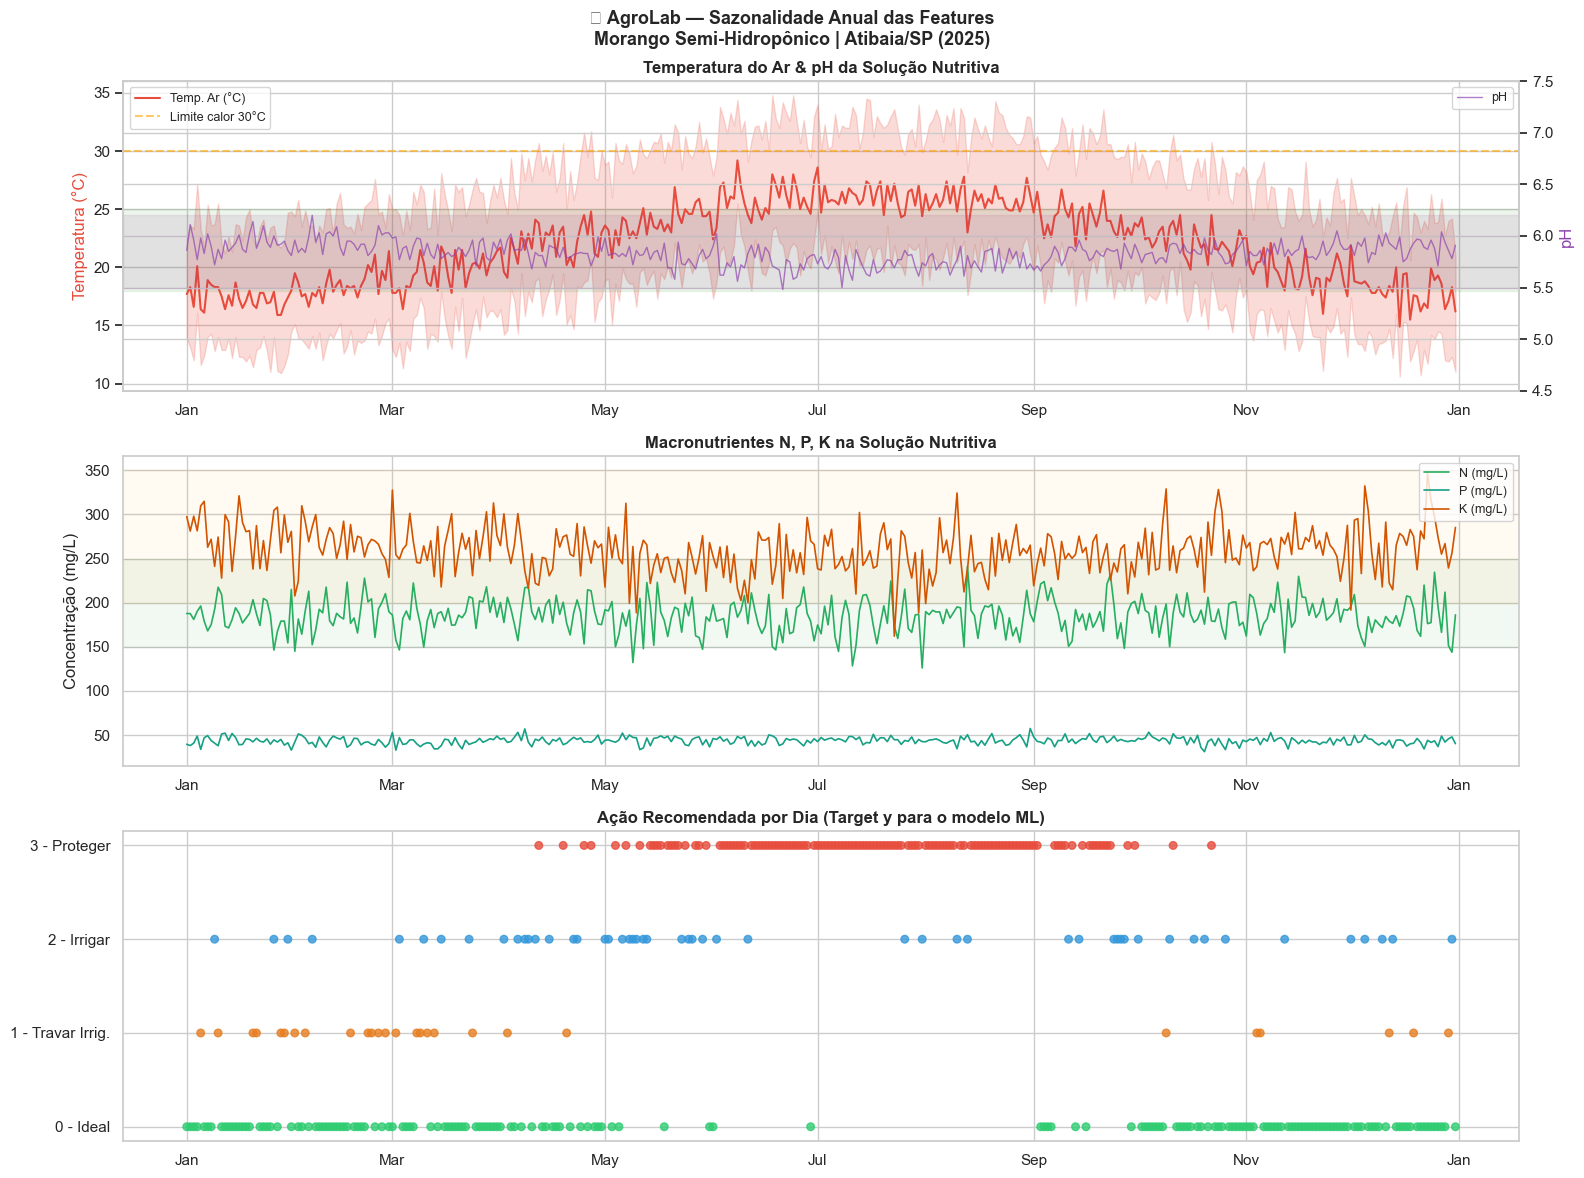

✅ Gráfico de sazonalidade anual salvo!


In [26]:
fig, axes = plt.subplots(3, 1, figsize=(16, 12))
fig.suptitle('🍓 AgroLab — Sazonalidade Anual das Features\nMorango Semi-Hidropônico | Atibaia/SP (2025)', 
             fontsize=13, fontweight='bold')

# Plot 1: Temperatura e pH
ax1 = axes[0]
ax1.fill_between(df_anual['data'], df_anual['temp_ar_min'], df_anual['temp_ar_max'],
                 alpha=0.2, color='#E74C3C')
ax1.plot(df_anual['data'], df_anual['temp_ar_media'], color='#E74C3C', linewidth=1.5, label='Temp. Ar (°C)')
ax1.axhspan(18, 25, alpha=0.08, color='green')
ax1.axhline(30, color='orange', linestyle='--', alpha=0.6, label='Limite calor 30°C')
ax1.set_ylabel('Temperatura (°C)', color='#E74C3C')
ax1.legend(loc='upper left', fontsize=9)

ax1b = ax1.twinx()
ax1b.plot(df_anual['data'], df_anual['pH'], color='#8E44AD', linewidth=1, alpha=0.7, label='pH')
ax1b.axhspan(5.5, 6.2, alpha=0.08, color='purple')
ax1b.set_ylabel('pH', color='#8E44AD')
ax1b.set_ylim(4.5, 7.5)
ax1b.legend(loc='upper right', fontsize=9)
ax1.set_title('Temperatura do Ar & pH da Solução Nutritiva', fontweight='bold')
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%b'))

# Plot 2: NPK
ax2 = axes[1]
ax2.plot(df_anual['data'], df_anual['N_mgL'], color='#27AE60', linewidth=1.2, label='N (mg/L)')
ax2.plot(df_anual['data'], df_anual['P_mgL'], color='#16A085', linewidth=1.2, label='P (mg/L)')
ax2.plot(df_anual['data'], df_anual['K_mgL'], color='#D35400', linewidth=1.2, label='K (mg/L)')
ax2.axhspan(150, 250, alpha=0.05, color='green')
ax2.axhspan(200, 350, alpha=0.05, color='orange')
ax2.set_ylabel('Concentração (mg/L)')
ax2.legend(loc='upper right', fontsize=9)
ax2.set_title('Macronutrientes N, P, K na Solução Nutritiva', fontweight='bold')
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%b'))

# Plot 3: Ação recomendada (target)
ax3 = axes[2]
scatter = ax3.scatter(df_anual['data'], df_anual['acao_label'],
                      c=df_anual['acao_label'].map(cores_acao),
                      s=30, alpha=0.8, zorder=3)
ax3.set_yticks([0, 1, 2, 3])
ax3.set_yticklabels(['0 - Ideal', '1 - Travar Irrig.', '2 - Irrigar', '3 - Proteger'])
ax3.set_title('Ação Recomendada por Dia (Target y para o modelo ML)', fontweight='bold')
ax3.xaxis.set_major_formatter(mdates.DateFormatter('%b'))

plt.tight_layout()
plt.savefig('sazonalidade_anual.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Gráfico de sazonalidade anual salvo!')

## 11. Estatísticas Descritivas e Correlações

📊 Estatísticas Descritivas — Dataset Anual (365 dias):
       temp_ar_media  umidade_ar_media  radiacao_PAR  chuva_mm      pH   N_mgL   P_mgL   K_mgL  temp_substrato  umidade_solo  luminosidade_lux
count         365.00            365.00        365.00    365.00  365.00  365.00  365.00  365.00          365.00        365.00            365.00
mean           21.96             72.22        484.28      3.99    5.83  185.22   43.56  259.45           19.41         67.79            337.64
std             3.35              9.07        167.05      6.27    0.11   19.28    4.24   26.94            3.41         10.86            117.35
min            14.90             53.00        112.60      0.00    5.48  126.10   31.20  162.10           12.00         40.70             71.60
25%            18.80             64.80        348.90      0.00    5.77  174.60   40.90  241.20           16.30         59.60            243.90
50%            22.20             71.70        492.30      0.90    5.83  186.50   43.90 

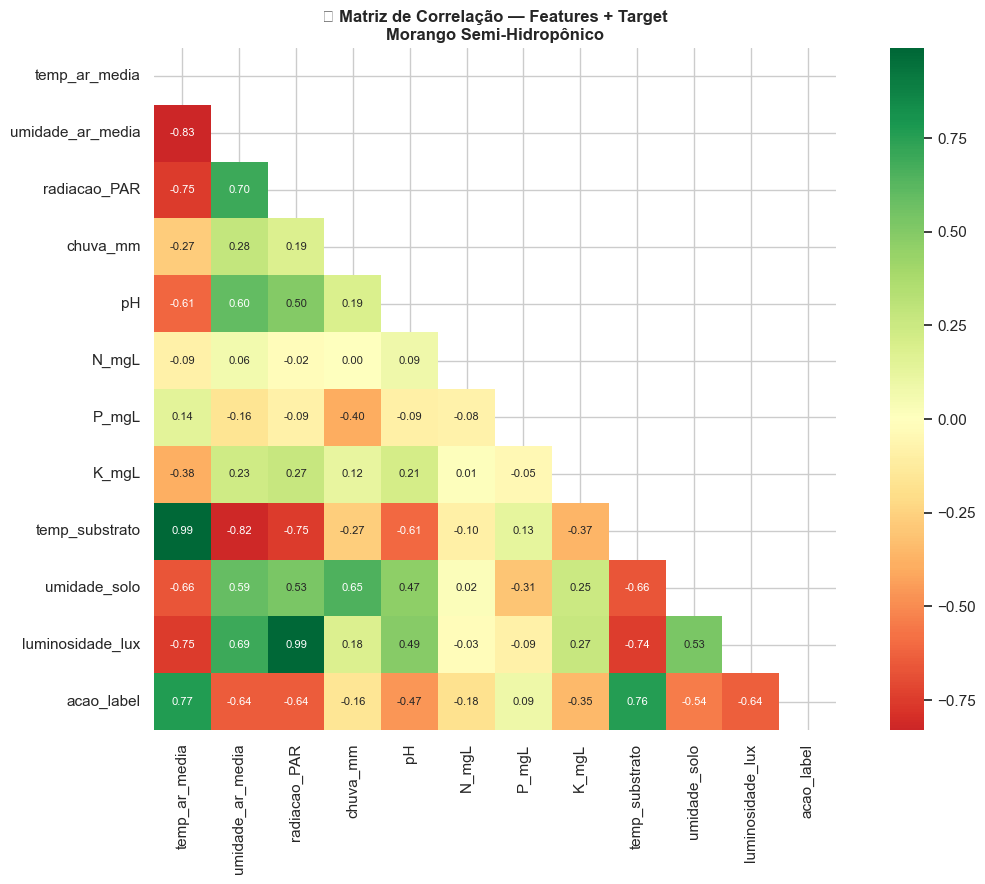

✅ Heatmap de correlações salvo!


In [27]:
features_cols = ['temp_ar_media', 'umidade_ar_media', 'radiacao_PAR', 'chuva_mm',
                 'pH', 'N_mgL', 'P_mgL', 'K_mgL', 
                 'temp_substrato', 'umidade_solo', 'luminosidade_lux']

print('📊 Estatísticas Descritivas — Dataset Anual (365 dias):')
print('='*75)
print(df_anual[features_cols].describe().round(2).to_string())

# Heatmap de correlações
fig, ax = plt.subplots(figsize=(12, 9))
corr = df_anual[features_cols + ['acao_label']].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn', center=0,
            square=True, ax=ax, mask=mask, annot_kws={'size': 8})
ax.set_title('🔗 Matriz de Correlação — Features + Target\nMorango Semi-Hidropônico', 
             fontweight='bold', fontsize=12)
plt.tight_layout()
plt.savefig('correlacoes.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Heatmap de correlações salvo!')

## 12. Exportação do Dataset Final

In [28]:
# Exportar CSV
csv_path = 'agrolab_morango_dataset.csv'
df_anual.to_csv(csv_path, index=False, sep=';', decimal=',', encoding='utf-8-sig')

print('💾 Dataset exportado com sucesso!')
print(f'   📂 Arquivo: {csv_path}')
print(f'   📏 Dimensões: {df_anual.shape[0]} linhas × {df_anual.shape[1]} colunas')
print()
print('📋 Colunas do dataset final:')
for col in df_anual.columns:
    print(f'   • {col}')

print()
print('📊 Primeiros 5 registros:')
print(df_anual.head().to_string(index=False))

💾 Dataset exportado com sucesso!
   📂 Arquivo: agrolab_morango_dataset.csv
   📏 Dimensões: 365 linhas × 18 colunas

📋 Colunas do dataset final:
   • data
   • temp_ar_media
   • temp_ar_max
   • temp_ar_min
   • umidade_ar_media
   • radiacao_PAR
   • chuva_mm
   • h_calor_extremo
   • h_umid_alta
   • pH
   • N_mgL
   • P_mgL
   • K_mgL
   • temp_substrato
   • umidade_solo
   • luminosidade_lux
   • acao_label
   • acao_nome

📊 Primeiros 5 registros:
      data  temp_ar_media  temp_ar_max  temp_ar_min  umidade_ar_media  radiacao_PAR  chuva_mm  h_calor_extremo  h_umid_alta   pH  N_mgL  P_mgL  K_mgL  temp_substrato  umidade_solo  luminosidade_lux  acao_label        acao_nome
2025-01-01           17.7         22.5         13.9              86.2         685.5       2.7                0            6 5.86  187.8   39.6  297.5            15.8          76.8             485.3           0            Ideal
2025-01-02           18.3         23.6         13.1              90.1         560.7      

In [29]:
df_anual['acao_nome'].value_counts()

acao_nome
Ideal               165
Proteger            122
Irrigar              51
Travar Irrigação     27
Name: count, dtype: int64

## 13. Resumo Técnico da Simulação

### Decisões de Modelagem

| Feature | Estratégia de Simulação | Justificativa Científica |
|---|---|---|
| **pH** | Base 5.85 + correção linear por Temp + ruído N(0, 0.08) | Acidificação por CO₂ dissolvido em altas temperaturas (Furlani, 2008) |
| **N (mg/L)** | Base 200 - 1.8×(T-22) - 0.02×(PAR-200) + ruído N(0,8) | Uptake aumenta com fotossíntese e temperatura |
| **P (mg/L)** | Base 45 - 0.5×chuva + ruído N(0,4) | Estável; leve diluição por eventos de chuva |
| **K (mg/L)** | Base 270 - 3×(T-22) + 1.5×(65-UR) + ruído N(0,15) | Osmorregulação aumenta consumo em estresse hídrico/térmico |
| **Temp. Substrato** | T_ar - 2.5°C + ruído N(0, 0.5) | Amortecimento térmico de calhas elevadas em estufa |
| **Umidade Solo** | Base 70 - 1.2×(T-22) + 0.8×chuva + 0.1×(UR-70) | Balanço evapotranspiração + recarga |
| **Luminosidade** | PAR × 0.70 + ruído N(0,15) | Transmissividade de filme PE de estufa (~70%) |

### Próximos Passos para a IC
1. **Ampliar o período real** com dados INMET para calibrar melhor os ruídos
2. **Adicionar fase fenológica** (vegetativa 0-30 dias / florescimento 30-60 / frutificação 60-90+)
3. **Estratificar NPK por fase** (N alto na vegetativa; K alto na frutificação)
4. **Treinar modelo baseline** (Random Forest) neste dataset simulado
5. **Validar com especialista agronômico** os coeficientes das funções de simulação